In [25]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

In [26]:
import jax
jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
from flax import linen as nn
import optax
import copy

from typing import Callable

from functools import partial

import tensorflow as tf
import tensorrt

from pyDOE import lhs
import numpy as np
import matplotlib.pyplot as plt

from scipy.integrate import odeint

import numpy as np

from jax.scipy.optimize import minimize
from scipy.optimize import fsolve

import warnings
import math

from collections import deque

In [27]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [28]:
print(jax.default_backend())

gpu


In [29]:
def flatten_pytree(params):
  values, tree_info = jax.tree_util.tree_flatten(params)

  no_leaves = len(values)
  shapes = []
  flattened = []

  for i in range(no_leaves):
    flattened.append(values[i].flatten())
    shapes.append(values[i].shape)

  return tree_info, shapes, jnp.concatenate(flattened)


def reconstruct_pytree(tree_info, shapes, flattened):

  values = []
  k = 0
  for i in range(len(shapes)):
    values.append(np.reshape(flattened[k:k+np.prod(shapes[i])], shapes[i]))
    k += np.prod(shapes[i])

  py_tree = jax.tree_util.tree_unflatten(tree_info, values)
  return py_tree

In [30]:
def doublePendulum(w, t):
    
    x1, x2, y1, y2 = w
    
    A = l1*l2*(m1 + m2*(jnp.sin(x1 - x2)**2))
    h1 = (y1*y2*jnp.sin(x1 - x2))/A
    h2 = (m2*(l2**2)*(y1**2) + (m1 + m2)*(l1**2)*(y2**2) - 2*m2*l1*l2*y1*y2*jnp.cos(x1 - x2))/(2*A**2)

    x1_t = (l2*y1 - l1*y2*jnp.cos(x1 - x2))/(l1*A)
    x2_t = (-m2*l2*y1*jnp.cos(x1 - x2) + l1*(m1 + m2)*y2)/(m2*l2*A)
    y1_t = -(m1 + m2)*grav*l1*jnp.sin(x1) - h1 + h2*jnp.sin(2*(x1 - x2))
    y2_t = -m2*grav*l2*jnp.sin(x2) + h1 - h2*jnp.sin(2*(x1 - x2))

    dwdt = [x1_t, x2_t, y1_t, y2_t]

    return dwdt

In [31]:
t0, tfinal = 0.0, 1.0

In [32]:
m1 = 1.0
m2 = 1.0
l1 = 1.0
l2 = 1.0
grav = 9.81

In [33]:
H_min = (m2*l2**2*0.0**2 + (m1+m2)*l1**2*0.0**2 - 2*m2*l1*l2*(np.pi/6)*(np.pi/6)*1.0) \
        /(2*m2*l1**2*l2**2*(m1+m2*(np.pi/6)**2)) \
        -(m1+m2)*grav*l1*1.0-m2*grav*l2*1.0

H_max = (m2*l2**2*(np.pi/6)**2 + (m1+m2)*l1**2*(np.pi/6)**2 - 2*m2*l1*l2*0.0*(np.pi/6)*1.0) \
        /(2*m2*l1**2*l2**2*(m1+m2*(np.pi/6)**2)) \
        -(m1+m2)*grav*l1*np.cos(np.pi/6)-m2*grav*l2*np.cos(np.pi/6)

print(H_min, H_max)

-29.645166547214764 -25.164377812553894


In [34]:
class Normalize(nn.Module):
  xmin: float
  xmax: float

  @nn.compact
  def __call__(self, x):
    return 2.0*(x-self.xmin)/(self.xmax - self.xmin) - 1.0

In [35]:
class HardConstraint(nn.Module):
  t0: float
  tfinal: float
  u0: float

  @nn.compact
  def __call__(self, inputs):
    t, nn = inputs
    return self.u0 + (t-self.t0)/(self.tfinal-self.t0)*nn

In [36]:
class CombineBranches(nn.Module):
  @nn.compact
  def __call__(self, inp1, inp2):
    mult = jnp.sum(inp1*inp2, axis=1)
    out = jnp.reshape(mult, (-1,1))
    return out

In [37]:
class MLP(nn.Module):

  layers: int
  units: int

  @nn.compact
  def __call__(self, inp):
    b = inp
    for i in range(self.layers-1):
      b = nn.Dense(self.units)(b)
      b = nn.tanh(b)
    out = nn.Dense(4*self.units)(b)
    return out

In [38]:
def define_collocation_points(t_bdry, N=100):

    ode_points = t_bdry[0] + (t_bdry[1] - t_bdry[0])*lhs(1, N)
    
    x1s = np.random.uniform(-np.pi/6, np.pi/6, size=(N, 1))
    x2s = np.random.uniform(-np.pi/6, np.pi/6, size=(N, 1))
    y1s = np.random.uniform(-np.pi/6, np.pi/6, size=(N, 1))
    y2s = np.random.uniform(-np.pi/6, np.pi/6, size=(N, 1))
    Hs = (m2*l2**2*y1s**2 + (m1+m2)*l1**2*y2s**2 - 2*m2*l1*l2*y1s*y2s*np.cos(x1s-x2s))/(2*m2*l1**2*l2**2*(m1+m2*np.sin(x1s-x2s)**2))-(m1+m2)*grav*l1*np.cos(x1s)-m2*grav*l2*np.cos(x2s)

    ode_points = np.column_stack((ode_points, Hs))
    zsensors = np.column_stack((x1s, x2s, y1s, y2s))
    
    return (ode_points, zsensors)

In [39]:
(de_points, zsensors) = define_collocation_points([t0, tfinal], 1000)
print(de_points.shape, zsensors.shape)

(1000, 2) (1000, 4)


In [40]:
H_vals = de_points[:, 1:]
Hmin = min(H_vals)[0]
Hmax = max(H_vals)[0]
print(Hmin, Hmax)

-29.389508082017578 -25.484018552231827


In [41]:
class VDeepONet(nn.Module):

  t0: float
  tfinal: float
  Hmin: float
  Hmax: float
  layers: int
  units: int

  @nn.compact
  def __call__(self, tH, u):

    if u.ndim == 1:
      u = jnp.reshape(u, (1,-1))

    if tH.ndim == 1:
      tH = jnp.reshape(tH, (1,-1))  

    t_0 = tH[:, :1]
    H_0 = tH[:, 1:]

    t_0 = jnp.reshape(t_0, (-1,1))
    t_0_norm = Normalize(self.t0, self.tfinal)(t_0)
   
    x1_0 = u[:, :1]
    x2_0 = u[:, 1:2]
    y1_0 = u[:, 2:3]
    y2_0 = u[:, 3:]

    b = t_0_norm

    trunk_net = MLP(self.layers, self.units)(b)
    branch_net = MLP(self.layers, self.units)(u)

    trunk_x1 = trunk_net[:, :self.units]
    trunk_x2 = trunk_net[:, self.units:2*self.units]
    trunk_y1 = trunk_net[:, 2*self.units:3*self.units]
    trunk_y2 = trunk_net[:, 3*self.units:]

    branch_x1 = branch_net[:, :self.units]
    branch_x2 = branch_net[:, self.units:2*self.units]
    branch_y1 = branch_net[:, 2*self.units:3*self.units]
    branch_y2 = branch_net[:, 3*self.units:]

    x1 = CombineBranches()(trunk_x1, branch_x1)
    x2 = CombineBranches()(trunk_x2, branch_x2)
    y1 = CombineBranches()(trunk_y1, branch_y1)
    y2 = CombineBranches()(trunk_y2, branch_y2)

    x1 = HardConstraint(self.t0, self.tfinal, x1_0)([t_0, x1])
    x2 = HardConstraint(self.t0, self.tfinal, x2_0)([t_0, x2])
    y1 = HardConstraint(self.t0, self.tfinal, y1_0)([t_0, y1])
    y2 = HardConstraint(self.t0, self.tfinal, y2_0)([t_0, y2])

    x1 = jnp.reshape(x1, (-1,))
    x2 = jnp.reshape(x2, (-1,))
    y1 = jnp.reshape(y1, (-1,))
    y2 = jnp.reshape(y2, (-1,))
    H = (m2*l2**2*y1**2 + (m1+m2)*l1**2*y2**2 - 2*m2*l1*l2*y1*y2*jnp.cos(x1-x2))/(2*m2*l1**2*l2**2*(m1+m2*jnp.sin(x1-x2)**2))-(m1+m2)*grav*l1*jnp.cos(x1)-m2*grav*l2*jnp.cos(x2)


    return x1, x2, y1, y2, H

In [42]:
@partial(jax.jit, static_argnums=(2,))
def Vvar_model(t, z, component, params):
  return Vdeeponet.apply(params, t, z)[component][0]

@partial(jax.jit, static_argnums=(2,))
def Vvar(t, z, component, params):
  return jax.vmap(Vvar_model, [0, 0, None, None])(t, z, component, params)

@partial(jax.jit, static_argnums=(2,))
def Vvar_t(t, z, component, params):
  return jax.vmap(jax.grad(Vvar_model, 0), [0, 0, None, None])(t, z, component, params)

@jax.jit
def Vloss(params, tH, z):

    x1_t_loss_w = 1.0
    x2_t_loss_w = 1.0
    y1_t_loss_w = 1.0
    y2_t_loss_w = 1.0
    
    diff_loss_w = 1.0
    H_loss_w = 1.0

    H_vals = tH[:, -1]

    x1 = Vvar(tH, z, 0, params)
    x2 = Vvar(tH, z, 1, params)
    y1 = Vvar(tH, z, 2, params)
    y2 = Vvar(tH, z, 3, params)

    dx1 = Vvar_t(tH, z, 0, params)
    x1_t = dx1[:, 0]

    dx2 = Vvar_t(tH, z, 1, params)
    x2_t = dx2[:, 0]

    dy1 = Vvar_t(tH, z, 2, params)
    y1_t = dy1[:, 0]
    
    dy2 = Vvar_t(tH, z, 3, params)
    y2_t = dy2[:, 0]

    dH = Vvar_t(tH, z, 4, params)
    H_t = dH[:, 0]
    H_t_loss = H_t
    H_t_loss = jnp.square(H_t_loss)
    H_t_loss = jnp.mean(H_t_loss)

    H = (m2*l2**2*y1**2 + (m1+m2)*l1**2*y2**2 - 2*m2*l1*l2*y1*y2*jnp.cos(x1-x2))/(2*m2*l1**2*l2**2*(m1+m2*jnp.sin(x1-x2)**2))-(m1+m2)*grav*l1*jnp.cos(x1)-m2*grav*l2*jnp.cos(x2)
 
    A = l1*l2*(m1 + m2*(jnp.sin(x1 - x2)**2))
    h1 = (y1*y2*jnp.sin(x1 - x2))/A
    h2 = (m2*(l2**2)*(y1**2) + (m1 + m2)*(l1**2)*(y2**2) - 2*m2*l1*l2*y1*y2*jnp.cos(x1 - x2))/(2*A**2)
    
    x1_t_loss = x1_t - (l2*y1 - l1*y2*jnp.cos(x1 - x2))/(l1*A)
    x1_t_loss = jnp.square(x1_t_loss)
    x1_t_loss = jnp.mean(x1_t_loss)
    
    x2_t_loss = x2_t - (-m2*l2*y1*jnp.cos(x1 - x2) + l1*(m1 + m2)*y2)/(m2*l2*A)
    x2_t_loss = jnp.square(x2_t_loss)
    x2_t_loss = jnp.mean(x2_t_loss)
    
    y1_t_loss = y1_t - (-(m1 + m2)*grav*l1*jnp.sin(x1) - h1 + h2*jnp.sin(2*(x1 - x2)))
    y1_t_loss = jnp.square(y1_t_loss)
    y1_t_loss = jnp.mean(y1_t_loss)
    
    y2_t_loss = y2_t - (-m2*grav*l2*jnp.sin(x2) + h1 - h2*jnp.sin(2*(x1 - x2)))
    y2_t_loss = jnp.square(y2_t_loss)
    y2_t_loss = jnp.mean(y2_t_loss)
    
    diff_loss = x1_t_loss_w*x1_t_loss + x2_t_loss_w*x2_t_loss + y1_t_loss_w*y1_t_loss + y2_t_loss_w*y2_t_loss

    H_loss = H - H_vals
    H_loss = jnp.square(H_loss)
    H_loss = jnp.mean(H_loss)    

    total_loss = diff_loss_w*diff_loss + H_loss_w*H_loss

    return total_loss, H_t_loss

@jax.jit
def Vtrain_step(params, pdes, z):
    tH = pdes
    
    return jax.value_and_grad(Vloss, has_aux = True)(params, tH, z)

@partial(jax.jit, static_argnums=(3,))
def Voptimize(grads, opt_state, params, optimizer_update):
    updates, opt_state = optimizer_update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state

In [43]:
def Vtrain_network(params, des, sensors, epochs=100):

    N = de_points.shape[0]
    
    nr_batches = 10
    batch_size = len(des)//nr_batches

    print(des.shape, N)
    print()
    
    print("batch size:", batch_size)
    
    lr = 1e-3
    optimizer = optax.adam(lr)
    opt_state = optimizer.init(params)
    
    ds_z = tf.data.Dataset.from_tensor_slices(sensors)
    ds_de = tf.data.Dataset.from_tensor_slices(des)
    
    ds = tf.data.Dataset.zip((ds_de, ds_z))
    ds = ds.shuffle(N).batch(batch_size)
    
    epoch_loss = np.zeros(epochs)
    epoch_aux_loss = np.zeros(epochs)

    for i in range(epochs):

        for (des_batch, z_batch) in ds:

            losses, grads = Vtrain_step(params, des_batch.numpy(), z_batch.numpy())
            loss, aux_loss = losses

            params, opt_state = Voptimize(grads, opt_state, params, optimizer.update)

            epoch_loss[i] += loss
            epoch_aux_loss[i] += aux_loss

        epoch_loss[i] /= batch_size

        if i % 100  == 0:
            print(f'Loss in epoch {i}: {epoch_loss[i]}')
            print(f'Aux Loss in epoch {i}: {epoch_aux_loss[i]}')

    return params, epoch_loss

In [44]:
Vdeeponet = VDeepONet(t0, tfinal, Hmin, Hmax, layers=4, units=40)

t_init = jnp.full((10, 2), 1.0)
u_init = jnp.full((10, 4), 1.0)

Vparams = Vdeeponet.init(jax.random.PRNGKey(0), t_init, u_init)

In [45]:
Vparam_count = sum(x.size for x in jax.tree.leaves(Vparams))
print(Vparam_count)

19960


In [46]:
tree_info, shapes, Vparams_flat = flatten_pytree(Vparams)
Vparams_flat = jnp.load("V_t1.0_1000_5000_ep_DP.npy")
print(Vparams_flat.shape)
Vparams = reconstruct_pytree(tree_info, shapes, Vparams_flat)

(19960,)


In [47]:
# epochs = 5000
# Vparams, loss = Vtrain_network(Vparams, de_points, zsensors, epochs)

# plt.semilogy(loss)
# plt.grid()

(500, 2) (500, 4)


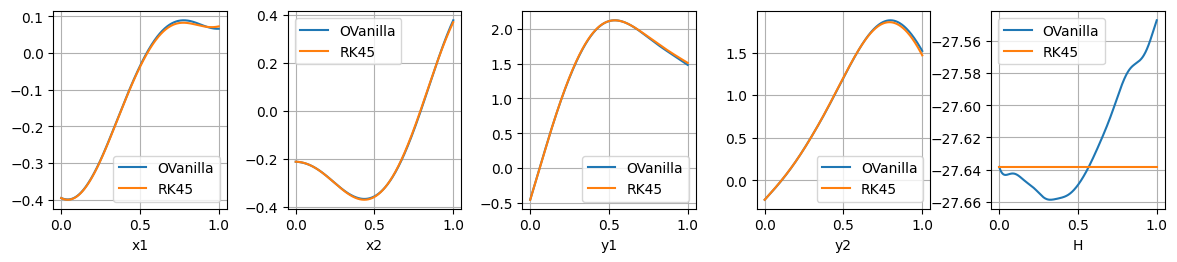

In [48]:
n = 500
t = np.linspace(t0, tfinal, n)

x1_init = np.random.uniform(-np.pi/6, np.pi/6, size=(1,))
x2_init = np.random.uniform(-np.pi/6, np.pi/6, size=(1,))
y1_init = np.random.uniform(-np.pi/6, np.pi/6, size=(1,))
y2_init = np.random.uniform(-np.pi/6, np.pi/6, size=(1,))
H_init = (m2*l2**2*y1_init**2 + (m1+m2)*l1**2*y2_init**2 - 2*m2*l1*l2*y1_init*y2_init*jnp.cos(x1_init-x2_init))/(2*m2*l1**2*l2**2*(m1+m2*jnp.sin(x1_init-x2_init)**2))-(m1+m2)*grav*l1*jnp.cos(x1_init)-m2*grav*l2*jnp.cos(x2_init)

data_rk = np.column_stack([x1_init, x2_init, y1_init, y2_init])
data_rk = np.reshape(data_rk, (-1,))
t_rk = t

sol_rk = odeint(doublePendulum, data_rk, t_rk, rtol = 1e-13, atol = 1e-13)
x1_rk, x2_rk, y1_rk, y2_rk = sol_rk[:, 0], sol_rk[:, 1], sol_rk[:, 2], sol_rk[:, 3]
H_rk = (m2*l2**2*y1_rk**2 + (m1+m2)*l1**2*y2_rk**2 - 2*m2*l1*l2*y1_rk*y2_rk*np.cos(x1_rk-x2_rk))/(2*m2*l1**2*l2**2*(m1+m2*np.sin(x1_rk-x2_rk)**2))-(m1+m2)*grav*l1*np.cos(x1_rk)-m2*grav*l2*np.cos(x2_rk)

H_data = np.repeat(np.expand_dims(H_init, axis=0), n, axis=0)
tH_data = np.column_stack([t, H_data])

x1x2y1y2_data = np.column_stack([x1_init, x2_init, y1_init, y2_init])
x1x2y1y2_data = np.reshape(x1x2y1y2_data, (-1,))
x1x2y1y2_data = np.repeat(np.expand_dims(x1x2y1y2_data, axis=0), n, axis=0)

print(tH_data.shape, x1x2y1y2_data.shape)

x1 = jax.vmap(Vvar_model, [0, 0, None, None])(tH_data, x1x2y1y2_data, 0, Vparams)
x2 = jax.vmap(Vvar_model, [0, 0, None, None])(tH_data, x1x2y1y2_data, 1, Vparams)
y1 = jax.vmap(Vvar_model, [0, 0, None, None])(tH_data, x1x2y1y2_data, 2, Vparams)
y2 = jax.vmap(Vvar_model, [0, 0, None, None])(tH_data, x1x2y1y2_data, 3, Vparams)
H = (m2*l2**2*y1**2 + (m1+m2)*l1**2*y2**2 - 2*m2*l1*l2*y1*y2*jnp.cos(x1-x2))/(2*m2*l1**2*l2**2*(m1+m2*jnp.sin(x1-x2)**2))-(m1+m2)*grav*l1*jnp.cos(x1)-m2*grav*l2*jnp.cos(x2)

fig = plt.figure(figsize=(12, 10))

plt.subplot(4, 5, 1)
plt.tight_layout()
plt.plot(t, x1, label = 'OVanilla')
plt.plot(t, x1_rk, label = 'RK45')
plt.xlabel("x1")
plt.grid()
plt.legend()

plt.subplot(4, 5, 2)
plt.tight_layout()
plt.plot(t, x2, label = 'OVanilla')
plt.plot(t, x2_rk, label = 'RK45')
plt.xlabel("x2")
plt.grid()
plt.legend()

plt.subplot(4, 5, 3)
plt.tight_layout()
plt.plot(t, y1, label = 'OVanilla')
plt.plot(t, y1_rk, label = 'RK45')
plt.xlabel("y1")
plt.grid()
plt.legend()

plt.subplot(4, 5, 4)
plt.tight_layout()
plt.plot(t, y2, label = 'OVanilla')
plt.plot(t, y2_rk, label = 'RK45')
plt.xlabel("y2")
plt.grid()
plt.legend()

plt.subplot(4, 5, 5)
plt.tight_layout()
plt.plot(t, H, label = 'OVanilla')
plt.plot(t, H_rk, label = 'RK45')
plt.xlabel("H")
plt.grid()
plt.legend()


In [49]:
class DeepONet(nn.Module):

  t0: float
  tfinal: float
  Hmin: float
  Hmax: float
  layers: int
  units: int

  @nn.compact
  def __call__(self, tH, u):

    if u.ndim == 1:
      u = jnp.reshape(u, (1,-1))

    if tH.ndim == 1:
      tH = jnp.reshape(tH, (1,-1))  

    t_0 = tH[:, :1]
    H_0 = tH[:, 1:]

    t_0 = jnp.reshape(t_0, (-1,1))
    t_0_norm = Normalize(self.t0, self.tfinal)(t_0)
      
    H_0_norm = Normalize(self.Hmin, self.Hmax)(H_0)
   
    x1_0 = u[:, :1]
    x2_0 = u[:, 1:2]
    y1_0 = u[:, 2:3]
    y2_0 = u[:, 3:]

    b = jnp.column_stack((t_0_norm, H_0_norm))

    trunk_net = MLP(self.layers, self.units)(b)
    branch_net = MLP(self.layers, self.units)(u)

    trunk_x1 = trunk_net[:, :self.units]
    trunk_x2 = trunk_net[:, self.units:2*self.units]
    trunk_y1 = trunk_net[:, 2*self.units:3*self.units]
    trunk_y2 = trunk_net[:, 3*self.units:]

    branch_x1 = branch_net[:, :self.units]
    branch_x2 = branch_net[:, self.units:2*self.units]
    branch_y1 = branch_net[:, 2*self.units:3*self.units]
    branch_y2 = branch_net[:, 3*self.units:]

    x1 = CombineBranches()(trunk_x1, branch_x1)
    x2 = CombineBranches()(trunk_x2, branch_x2)
    y1 = CombineBranches()(trunk_y1, branch_y1)
    y2 = CombineBranches()(trunk_y2, branch_y2)

    x1 = HardConstraint(self.t0, self.tfinal, x1_0)([t_0, x1])
    x2 = HardConstraint(self.t0, self.tfinal, x2_0)([t_0, x2])
    y1 = HardConstraint(self.t0, self.tfinal, y1_0)([t_0, y1])
    y2 = HardConstraint(self.t0, self.tfinal, y2_0)([t_0, y2])

    x1 = jnp.reshape(x1, (-1,))
    x2 = jnp.reshape(x2, (-1,))
    y1 = jnp.reshape(y1, (-1,))
    y2 = jnp.reshape(y2, (-1,))
    H = (m2*l2**2*y1**2 + (m1+m2)*l1**2*y2**2 - 2*m2*l1*l2*y1*y2*jnp.cos(x1-x2))/(2*m2*l1**2*l2**2*(m1+m2*jnp.sin(x1-x2)**2))-(m1+m2)*grav*l1*jnp.cos(x1)-m2*grav*l2*jnp.cos(x2)


    return x1, x2, y1, y2, H

In [50]:
@partial(jax.jit, static_argnums=(2,))
def var_model(t, z, component, params):
  return deeponet.apply(params, t, z)[component][0]

@partial(jax.jit, static_argnums=(2,))
def var(t, z, component, params):
  return jax.vmap(var_model, [0, 0, None, None])(t, z, component, params)

@partial(jax.jit, static_argnums=(2,))
def var_t(t, z, component, params):
  return jax.vmap(jax.grad(var_model, 0), [0, 0, None, None])(t, z, component, params)

@jax.jit
def loss(params, tH, z):

    x1_t_loss_w = 1.0
    x2_t_loss_w = 1.0
    y1_t_loss_w = 1.0
    y2_t_loss_w = 1.0
    
    diff_loss_w = 1.0
    H_loss_w = 0.01

    H_vals = tH[:, -1]
    
    x1 = var(tH, z, 0, params)
    x2 = var(tH, z, 1, params)
    y1 = var(tH, z, 2, params)
    y2 = var(tH, z, 3, params)

    dx1 = var_t(tH, z, 0, params)
    x1_t = dx1[:, 0]

    dx2 = var_t(tH, z, 1, params)
    x2_t = dx2[:, 0]

    dy1 = var_t(tH, z, 2, params)
    y1_t = dy1[:, 0]
    
    dy2 = var_t(tH, z, 3, params)
    y2_t = dy2[:, 0]

    dH = var_t(tH, z, 4, params)
    H_t = dH[:, 0]
    H_t_loss = H_t
    H_t_loss = jnp.square(H_t_loss)
    H_t_loss = jnp.mean(H_t_loss)
    
    H = (m2*l2**2*y1**2 + (m1+m2)*l1**2*y2**2 - 2*m2*l1*l2*y1*y2*jnp.cos(x1-x2))/(2*m2*l1**2*l2**2*(m1+m2*jnp.sin(x1-x2)**2))-(m1+m2)*grav*l1*jnp.cos(x1)-m2*grav*l2*jnp.cos(x2)
 
    A = l1*l2*(m1 + m2*(jnp.sin(x1 - x2)**2))
    h1 = (y1*y2*jnp.sin(x1 - x2))/A
    h2 = (m2*(l2**2)*(y1**2) + (m1 + m2)*(l1**2)*(y2**2) - 2*m2*l1*l2*y1*y2*jnp.cos(x1 - x2))/(2*A**2)
    
    x1_t_loss = x1_t - (l2*y1 - l1*y2*jnp.cos(x1 - x2))/(l1*A)
    x1_t_loss = jnp.square(x1_t_loss)
    x1_t_loss = jnp.mean(x1_t_loss)
    
    x2_t_loss = x2_t - (-m2*l2*y1*jnp.cos(x1 - x2) + l1*(m1 + m2)*y2)/(m2*l2*A)
    x2_t_loss = jnp.square(x2_t_loss)
    x2_t_loss = jnp.mean(x2_t_loss)
    
    y1_t_loss = y1_t - (-(m1 + m2)*grav*l1*jnp.sin(x1) - h1 + h2*jnp.sin(2*(x1 - x2)))
    y1_t_loss = jnp.square(y1_t_loss)
    y1_t_loss = jnp.mean(y1_t_loss)
    
    y2_t_loss = y2_t - (-m2*grav*l2*jnp.sin(x2) + h1 - h2*jnp.sin(2*(x1 - x2)))
    y2_t_loss = jnp.square(y2_t_loss)
    y2_t_loss = jnp.mean(y2_t_loss)
    
    diff_loss = x1_t_loss_w*x1_t_loss + x2_t_loss_w*x2_t_loss + y1_t_loss_w*y1_t_loss + y2_t_loss_w*y2_t_loss

    H_loss = H - H_vals
    H_loss = jnp.square(H_loss)
    H_loss = jnp.mean(H_loss)    

    total_loss = diff_loss_w*diff_loss + H_loss_w*H_loss

    return total_loss, H_loss

@jax.jit
def train_step(params, pdes, z):
    tH = pdes
    
    return jax.value_and_grad(loss, has_aux = True)(params, tH, z)

@partial(jax.jit, static_argnums=(3,))
def optimize(grads, opt_state, params, optimizer_update):
    updates, opt_state = optimizer_update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state

In [51]:
def train_network(params, des, sensors, epochs=100):

    N = de_points.shape[0]
    
    nr_batches = 10
    batch_size = len(des)//nr_batches
    
    print("batch size:", batch_size)
    
    lr = 1e-3
    optimizer = optax.adam(lr)
    opt_state = optimizer.init(params)
    
    ds_z = tf.data.Dataset.from_tensor_slices(sensors)
    ds_de = tf.data.Dataset.from_tensor_slices(des)
    
    ds = tf.data.Dataset.zip((ds_de, ds_z))
    ds = ds.shuffle(N).batch(batch_size)
    
    epoch_loss = np.zeros(epochs)
    epoch_aux_loss = np.zeros(epochs)

    for i in range(epochs):

        for (des_batch, z_batch) in ds:

            losses, grads = train_step(params, des_batch.numpy(), z_batch.numpy())
            loss, aux_loss = losses

            params, opt_state = optimize(grads, opt_state, params, optimizer.update)

            epoch_loss[i] += loss
            epoch_aux_loss[i] += aux_loss

        epoch_loss[i] /= batch_size

        if i % 1  == 0:
            print(f'Loss in epoch {i}: {epoch_loss[i]}')
            print(f'Aux Loss in epoch {i}: {epoch_aux_loss[i]}')

    return params, epoch_loss

In [52]:
deeponet = DeepONet(t0, tfinal, Hmin, Hmax, layers=4, units=40)

t_init = jnp.full((10, 2), 1.0)
u_init = jnp.full((10, 4), 1.0)

params = deeponet.init(jax.random.PRNGKey(0), t_init, u_init)

In [53]:
param_count = sum(x.size for x in jax.tree.leaves(params))
print(param_count)

20000


In [54]:
tree_info, shapes, params_flat = flatten_pytree(params)
params_flat = jnp.load("P_t1.0_1000_5000_ep_DP.npy")
print(params_flat.shape)
params = reconstruct_pytree(tree_info, shapes, params_flat)

(20000,)


In [55]:
# epochs = 2000
# params, loss = train_network(params, de_points, zsensors, epochs)

# plt.semilogy(loss)
# plt.grid()

(500, 2) (500, 4)


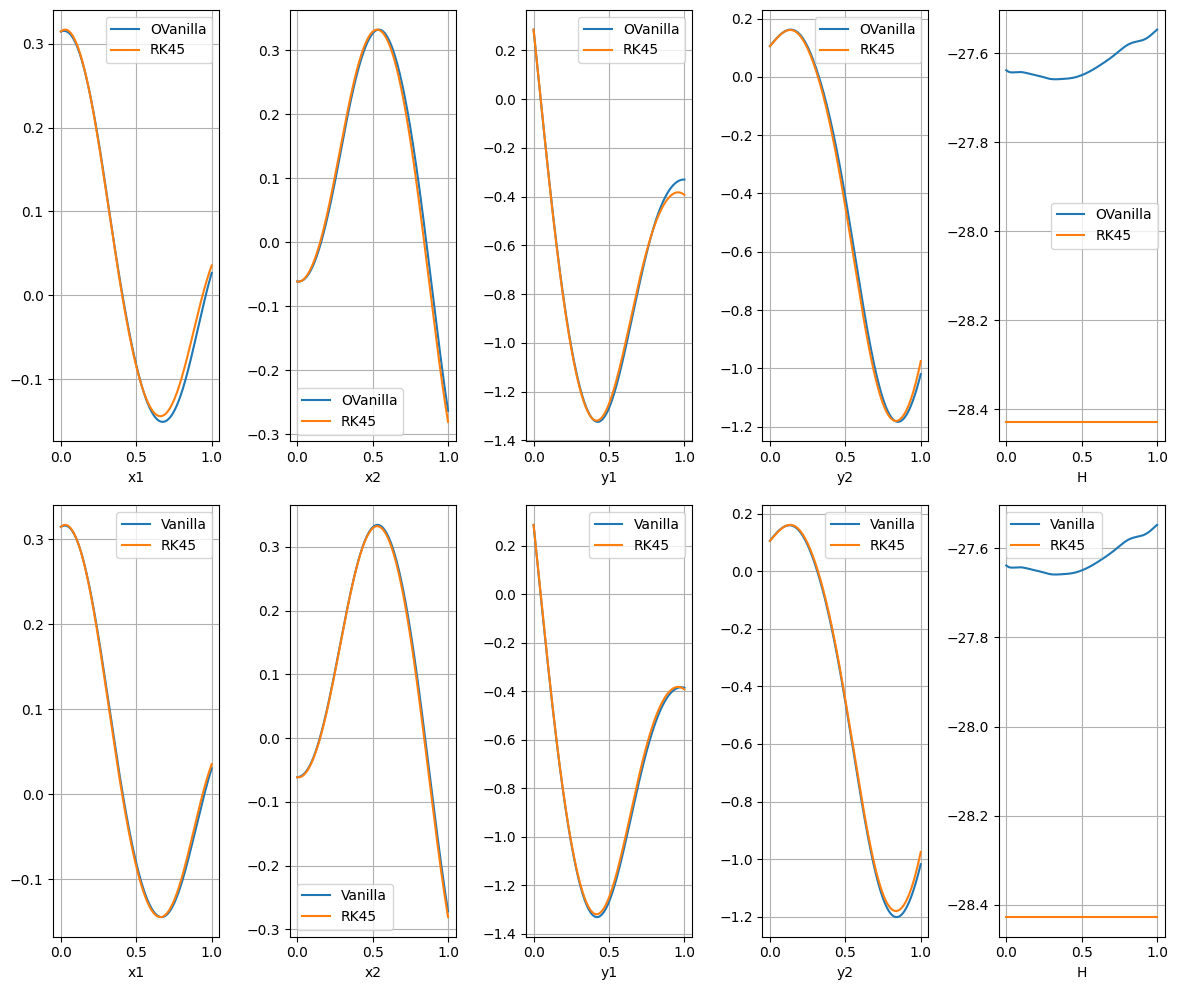

In [56]:
n = 500
t = np.linspace(t0, tfinal, n)

x1_init = np.random.uniform(-np.pi/6, np.pi/6, size=(1,))
x2_init = np.random.uniform(-np.pi/6, np.pi/6, size=(1,))
y1_init = np.random.uniform(-np.pi/6, np.pi/6, size=(1,))
y2_init = np.random.uniform(-np.pi/6, np.pi/6, size=(1,))
H_init = (m2*l2**2*y1_init**2 + (m1+m2)*l1**2*y2_init**2 - 2*m2*l1*l2*y1_init*y2_init*jnp.cos(x1_init-x2_init))/(2*m2*l1**2*l2**2*(m1+m2*jnp.sin(x1_init-x2_init)**2))-(m1+m2)*grav*l1*jnp.cos(x1_init)-m2*grav*l2*jnp.cos(x2_init)

data_rk = np.column_stack([x1_init, x2_init, y1_init, y2_init])
data_rk = np.reshape(data_rk, (-1,))
t_rk = t

sol_rk = odeint(doublePendulum, data_rk, t_rk, rtol = 1e-13, atol = 1e-13)
x1_rk, x2_rk, y1_rk, y2_rk = sol_rk[:, 0], sol_rk[:, 1], sol_rk[:, 2], sol_rk[:, 3]
H_rk = (m2*l2**2*y1_rk**2 + (m1+m2)*l1**2*y2_rk**2 - 2*m2*l1*l2*y1_rk*y2_rk*np.cos(x1_rk-x2_rk))/(2*m2*l1**2*l2**2*(m1+m2*np.sin(x1_rk-x2_rk)**2))-(m1+m2)*grav*l1*np.cos(x1_rk)-m2*grav*l2*np.cos(x2_rk)

H_data = np.repeat(np.expand_dims(H_init, axis=0), n, axis=0)
tH_data = np.column_stack([t, H_data])

x1x2y1y2_data = np.column_stack([x1_init, x2_init, y1_init, y2_init])
x1x2y1y2_data = np.reshape(x1x2y1y2_data, (-1,))
x1x2y1y2_data = np.repeat(np.expand_dims(x1x2y1y2_data, axis=0), n, axis=0)

print(tH_data.shape, x1x2y1y2_data.shape)

x1_ovan = jax.vmap(Vvar_model, [0, 0, None, None])(tH_data, x1x2y1y2_data, 0, Vparams)
x2_ovan = jax.vmap(Vvar_model, [0, 0, None, None])(tH_data, x1x2y1y2_data, 1, Vparams)
y1_ovan = jax.vmap(Vvar_model, [0, 0, None, None])(tH_data, x1x2y1y2_data, 2, Vparams)
y2_ovan = jax.vmap(Vvar_model, [0, 0, None, None])(tH_data, x1x2y1y2_data, 3, Vparams)
H_ovan = (m2*l2**2*y1**2 + (m1+m2)*l1**2*y2**2 - 2*m2*l1*l2*y1*y2*jnp.cos(x1-x2))/(2*m2*l1**2*l2**2*(m1+m2*jnp.sin(x1-x2)**2))-(m1+m2)*grav*l1*jnp.cos(x1)-m2*grav*l2*jnp.cos(x2)


x1_van = jax.vmap(var_model, [0, 0, None, None])(tH_data, x1x2y1y2_data, 0, params)
x2_van = jax.vmap(var_model, [0, 0, None, None])(tH_data, x1x2y1y2_data, 1, params)
y1_van = jax.vmap(var_model, [0, 0, None, None])(tH_data, x1x2y1y2_data, 2, params)
y2_van = jax.vmap(var_model, [0, 0, None, None])(tH_data, x1x2y1y2_data, 3, params)
H_van = (m2*l2**2*y1**2 + (m1+m2)*l1**2*y2**2 - 2*m2*l1*l2*y1*y2*jnp.cos(x1-x2))/(2*m2*l1**2*l2**2*(m1+m2*jnp.sin(x1-x2)**2))-(m1+m2)*grav*l1*jnp.cos(x1)-m2*grav*l2*jnp.cos(x2)

fig = plt.figure(figsize=(12, 10))

plt.subplot(2, 5, 1)
plt.tight_layout()
plt.plot(t, x1_ovan, label = 'OVanilla')
plt.plot(t, x1_rk, label = 'RK45')
plt.xlabel("x1")
plt.grid()
plt.legend()

plt.subplot(2, 5, 2)
plt.tight_layout()
plt.plot(t, x2_ovan, label = 'OVanilla')
plt.plot(t, x2_rk, label = 'RK45')
plt.xlabel("x2")
plt.grid()
plt.legend()

plt.subplot(2, 5, 3)
plt.tight_layout()
plt.plot(t, y1_ovan, label = 'OVanilla')
plt.plot(t, y1_rk, label = 'RK45')
plt.xlabel("y1")
plt.grid()
plt.legend()

plt.subplot(2, 5, 4)
plt.tight_layout()
plt.plot(t, y2_ovan, label = 'OVanilla')
plt.plot(t, y2_rk, label = 'RK45')
plt.xlabel("y2")
plt.grid()
plt.legend()

plt.subplot(2, 5, 5)
plt.tight_layout()
plt.plot(t, H_ovan, label = 'OVanilla')
plt.plot(t, H_rk, label = 'RK45')
plt.xlabel("H")
plt.grid()
plt.legend()

plt.subplot(2, 5, 6)
plt.tight_layout()
plt.plot(t, x1_van, label = 'Vanilla')
plt.plot(t, x1_rk, label = 'RK45')
plt.xlabel("x1")
plt.grid()
plt.legend()

plt.subplot(2, 5, 7)
plt.tight_layout()
plt.plot(t, x2_van, label = 'Vanilla')
plt.plot(t, x2_rk, label = 'RK45')
plt.xlabel("x2")
plt.grid()
plt.legend()

plt.subplot(2, 5, 8)
plt.tight_layout()
plt.plot(t, y1_van, label = 'Vanilla')
plt.plot(t, y1_rk, label = 'RK45')
plt.xlabel("y1")
plt.grid()
plt.legend()

plt.subplot(2, 5, 9)
plt.tight_layout()
plt.plot(t, y2_van, label = 'Vanilla')
plt.plot(t, y2_rk, label = 'RK45')
plt.xlabel("y2")
plt.grid()
plt.legend()

plt.subplot(2, 5, 10)
plt.tight_layout()
plt.plot(t, H_van, label = 'Vanilla')
plt.plot(t, H_rk, label = 'RK45')
plt.xlabel("H")
plt.grid()
plt.legend()

In [57]:
@jax.jit
def gradD_fun(x, H_0) :

    x1 = x[0]
    x2 = x[1]
    y1 = x[2]
    y2 = x[3]
    
    A = l1*l2*(m1 + m2*(jnp.sin(x1 - x2)**2))
    h1 = (y1*y2*jnp.sin(x1 - x2))/A
    h2 = (m2*(l2**2)*(y1**2) + (m1 + m2)*(l1**2)*(y2**2) - 2*m2*l1*l2*y1*y2*jnp.cos(x1 - x2))/(2*A**2)

    H = (m2*l2**2*y1**2 + (m1+m2)*l1**2*y2**2 - 2*m2*l1*l2*y1*y2*jnp.cos(x1-x2))/(2*m2*l1**2*l2**2*(m1+m2*jnp.sin(x1-x2)**2))-(m1+m2)*grav*l1*jnp.cos(x1)-m2*grav*l2*jnp.cos(x2)

    dH_dx1 = (m1 + m2)*grav*l1*jnp.sin(x1) + h1 - h2*jnp.sin(2*(x1 - x2))
    dH_dx2 = m2*grav*l2*jnp.sin(x2) - h1 + h2*jnp.sin(2*(x1 - x2))
    dH_dy1 = (l2*y1 - l1*y2*jnp.cos(x1-x2))/(l1*A)
    dH_dy2 = (l1*(m1+m2)*y2 - m2*l2*y1*jnp.cos(x1-x2))/(m2*l2*A)

    dD_dx1 = 2*(H_0 - H)*-dH_dx1
    dD_dx2 = 2*(H_0 - H)*-dH_dx2
    dD_dy1 = 2*(H_0 - H)*-dH_dy1
    dD_dy2 = 2*(H_0 - H)*-dH_dy2

    deriv_D_arr = jnp.array([dD_dx1, dD_dx2, dD_dy1, dD_dy2])

    return deriv_D_arr

In [58]:
@jax.jit
def D_fun(x, H_0) :

    x1 = x[0]
    x2 = x[1]
    y1 = x[2]
    y2 = x[3]
        
    H = (m2*l2**2*y1**2 + (m1+m2)*l1**2*y2**2 - 2*m2*l1*l2*y1*y2*jnp.cos(x1-x2))/(2*m2*l1**2*l2**2*(m1+m2*jnp.sin(x1-x2)**2))-(m1+m2)*grav*l1*jnp.cos(x1)-m2*grav*l2*jnp.cos(x2)

    D = (H_0 - H)**2

    D_arr = jnp.array([D])

    return D_arr

In [59]:
@jax.jit
def find_rec(x):
    
    x = x + jnp.finfo(jnp.float64).eps
    
    return 1/x

In [60]:
@jax.jit
def wolfe_conds(args):

    alpha, curr_x, curr_f, curr_grad, next_x, next_f, next_grad, p, H_0, iter = args

    c1 = 1e-4

    cond = next_f - curr_f - c1*alpha*(curr_grad.T@p)

    cond_bool = jax.lax.cond(cond[0][0] > 0.0 , lambda x: True, lambda x: False, None)
    final_bool = cond_bool
    
    return final_bool

In [61]:
@jax.jit
def update_alpha(args) :

    alpha, curr_x, curr_f, curr_grad, next_x, next_f, next_grad, p, H_0, iter = args

    alpha = alpha*0.1
    iter = iter + 1
        
    next_x = curr_x + alpha*p
    next_f = D_fun(next_x, H_0)
    next_grad = gradD_fun(next_x, H_0) 
   
    return (alpha, curr_x, curr_f, curr_grad, next_x, next_f, next_grad, p, H_0, iter)


In [62]:
@jax.jit
def BFGS(x, H_0) :

    iter_num = 0
    init_iter = 0
    alpha = 1.0
    I_4 = jnp.identity(4, dtype = jnp.float64)
    B_0_inv = jnp.identity(4, dtype = jnp.float64)

    x_0 = x
    x_0 = jnp.reshape(x_0, (-1, 1))

    D_0 = D_fun(x_0, H_0)
    gradD_0 = gradD_fun(x_0, H_0)

    p = -(B_0_inv@gradD_0)

    pot_x = x_0 + alpha*p
    pot_D = D_fun(pot_x, H_0)
    pot_gradD = gradD_fun(pot_x, H_0)

    init_args = (alpha, x_0, D_0, gradD_0, pot_x, pot_D, pot_gradD, p, H_0, init_iter)
    
    step, _, _, _, _, _, _, _, _, _ = jax.lax.while_loop(wolfe_conds, update_alpha, init_args)

    x_1 = x_0 + step*p

    while iter_num < 10:

        delta_x = x_1 - x_0

        D_1 = D_fun(x_1, H_0)
        gradD_1 = gradD_fun(x_1, H_0)

        y = gradD_1 - gradD_0       

        y_T_delta_x = y.T@delta_x
        y_T_delta_x_rec = find_rec(y_T_delta_x)
        
        B_1_inv = ((I_4 - (y_T_delta_x_rec*(delta_x@y.T)))@B_0_inv@(I_4 - (y_T_delta_x_rec*(y@delta_x.T)))) + (y_T_delta_x_rec*(delta_x@delta_x.T))   
        p = -(B_1_inv@gradD_1)
        
        pot_x = x_1 + alpha*p
        pot_D = D_fun(pot_x, H_0)
        pot_gradD = gradD_fun(pot_x, H_0) 
                  
        init_args = (alpha, x_1, D_1, gradD_1, pot_x, pot_D, pot_gradD, p, H_0, init_iter)

        step, _, _, _, _, _, _, _, _, _ = jax.lax.while_loop(wolfe_conds, update_alpha, init_args)

        x_temp = x_1 + step*p

        x_0 = x_1
        x_1 = x_temp

        D_0 = D_1
        gradD_0 = gradD_1

        B_0_inv = B_1_inv
        
        iter_num = iter_num + 1

    x1 = x_1[0]
    x2 = x_1[1]
    y1 = x_1[2]
    y2 = x_1[3]

    x1 = jnp.reshape(x1, (-1,))[0]
    x2 = jnp.reshape(x2, (-1,))[0]
    y1 = jnp.reshape(y1, (-1,))[0]
    y2 = jnp.reshape(y2, (-1,))[0]

    return x_1

In [63]:
@jax.jit
def find_min_bfgs(x, H_0) :

    return jax.vmap(BFGS, (0, 0), 0)(x, H_0)

In [64]:
class ClosestPoint(nn.Module):

    H_0: float
    
    @nn.compact
    def __call__(self, inputs):
    
        z_min = find_min_bfgs(inputs, self.H_0)
    
        return z_min

In [65]:
class CDeepONet(nn.Module):

  t0: float
  tfinal: float
  Hmin: float
  Hmax: float
  layers: int
  units: int

  @nn.compact
  def __call__(self, tH, u):

    if u.ndim == 1:
      u = jnp.reshape(u, (1,-1))

    if tH.ndim == 1:
      tH = jnp.reshape(tH, (1,-1))  

      
    t_0 = tH[:, :1]
    H_0 = tH[:, 1:]

    t_0 = jnp.reshape(t_0, (-1,1))
    t_0_norm = Normalize(self.t0, self.tfinal)(t_0)

    H_0_norm = Normalize(self.Hmin, self.Hmax)(H_0)
   
    x1_0 = u[:, :1]
    x2_0 = u[:, 1:2]
    y1_0 = u[:, 2:3]
    y2_0 = u[:, 3:]

    b = jnp.column_stack((t_0_norm, H_0_norm)) 

    trunk_net = MLP(self.layers, self.units)(b)
    branch_net = MLP(self.layers, self.units)(u)

    trunk_x1 = trunk_net[:, :self.units]
    trunk_x2 = trunk_net[:, self.units:2*self.units]
    trunk_y1 = trunk_net[:, 2*self.units:3*self.units]
    trunk_y2 = trunk_net[:, 3*self.units:]

    branch_x1 = branch_net[:, :self.units]
    branch_x2 = branch_net[:, self.units:2*self.units]
    branch_y1 = branch_net[:, 2*self.units:3*self.units]
    branch_y2 = branch_net[:, 3*self.units:]

    x1 = CombineBranches()(trunk_x1, branch_x1)
    x2 = CombineBranches()(trunk_x2, branch_x2)
    y1 = CombineBranches()(trunk_y1, branch_y1)
    y2 = CombineBranches()(trunk_y2, branch_y2)

    x1 = HardConstraint(self.t0, self.tfinal, x1_0)([t_0, x1])
    x2 = HardConstraint(self.t0, self.tfinal, x2_0)([t_0, x2])
    y1 = HardConstraint(self.t0, self.tfinal, y1_0)([t_0, y1])
    y2 = HardConstraint(self.t0, self.tfinal, y2_0)([t_0, y2])

    # z = jnp.column_stack([x1, x2, y1, y2])
    # z = ClosestPoint(H_0)(z)   

    # x1 = z[:, :1]
    # x2 = z[:, 1:2]
    # y1 = z[:, 2:3]
    # y2 = z[:, 3:]

    x1 = jnp.reshape(x1, (-1,))
    x2 = jnp.reshape(x2, (-1,))
    y1 = jnp.reshape(y1, (-1,))
    y2 = jnp.reshape(y2, (-1,))
    H = (m2*l2**2*y1**2 + (m1+m2)*l1**2*y2**2 - 2*m2*l1*l2*y1*y2*jnp.cos(x1-x2))/(2*m2*l1**2*l2**2*(m1+m2*jnp.sin(x1-x2)**2))-(m1+m2)*grav*l1*jnp.cos(x1)-m2*grav*l2*jnp.cos(x2)


    return x1, x2, y1, y2, H

In [66]:
@partial(jax.jit, static_argnums=(2,))
def Cvar_model(t, z, component, params):
  return Cdeeponet.apply(params, t, z)[component][0]

@partial(jax.jit, static_argnums=(2,))
def Cvar(t, z, component, params):
  return jax.vmap(Cvar_model, [0, 0, None, None])(t, z, component, params)

@partial(jax.jit, static_argnums=(2,))
def Cvar_t(t, z, component, params):
  return jax.vmap(jax.grad(Cvar_model, 0), [0, 0, None, None])(t, z, component, params)

@jax.jit
def Closs(params, tH, z):

    x1_t_loss_w = 1.0
    x2_t_loss_w = 1.0
    y1_t_loss_w = 1.0
    y2_t_loss_w = 1.0
    
    diff_loss_w = 1.0
    H_loss_w = 0.0

    H_vals = tH[:, -1]

    x1 = Cvar(tH, z, 0, params)
    x2 = Cvar(tH, z, 1, params)
    y1 = Cvar(tH, z, 2, params)
    y2 = Cvar(tH, z, 3, params)

    dx1 = Cvar_t(tH, z, 0, params)
    x1_t = dx1[:, 0]

    dx2 = Cvar_t(tH, z, 1, params)
    x2_t = dx2[:, 0]

    dy1 = Cvar_t(tH, z, 2, params)
    y1_t = dy1[:, 0]
    
    dy2 = Cvar_t(tH, z, 3, params)
    y2_t = dy2[:, 0]

    dH = Cvar_t(tH, z, 4, params)
    H_t = dH[:, 0]
    H_t_loss = H_t
    H_t_loss = jnp.square(H_t_loss)
    H_t_loss = jnp.mean(H_t_loss)
    
    H = (m2*l2**2*y1**2 + (m1+m2)*l1**2*y2**2 - 2*m2*l1*l2*y1*y2*jnp.cos(x1-x2))/(2*m2*l1**2*l2**2*(m1+m2*jnp.sin(x1-x2)**2))-(m1+m2)*grav*l1*jnp.cos(x1)-m2*grav*l2*jnp.cos(x2)
 
    A = l1*l2*(m1 + m2*(jnp.sin(x1 - x2)**2))
    h1 = (y1*y2*jnp.sin(x1 - x2))/A
    h2 = (m2*(l2**2)*(y1**2) + (m1 + m2)*(l1**2)*(y2**2) - 2*m2*l1*l2*y1*y2*jnp.cos(x1 - x2))/(2*A**2)
    
    x1_t_loss = x1_t - (l2*y1 - l1*y2*jnp.cos(x1 - x2))/(l1*A)
    x1_t_loss = jnp.square(x1_t_loss)
    x1_t_loss = jnp.mean(x1_t_loss)
    
    x2_t_loss = x2_t - (-m2*l2*y1*jnp.cos(x1 - x2) + l1*(m1 + m2)*y2)/(m2*l2*A)
    x2_t_loss = jnp.square(x2_t_loss)
    x2_t_loss = jnp.mean(x2_t_loss)
    
    y1_t_loss = y1_t - (-(m1 + m2)*grav*l1*jnp.sin(x1) - h1 + h2*jnp.sin(2*(x1 - x2)))
    y1_t_loss = jnp.square(y1_t_loss)
    y1_t_loss = jnp.mean(y1_t_loss)
    
    y2_t_loss = y2_t - (-m2*grav*l2*jnp.sin(x2) + h1 - h2*jnp.sin(2*(x1 - x2)))
    y2_t_loss = jnp.square(y2_t_loss)
    y2_t_loss = jnp.mean(y2_t_loss)
    
    diff_loss = x1_t_loss_w*x1_t_loss + x2_t_loss_w*x2_t_loss + y1_t_loss_w*y1_t_loss + y2_t_loss_w*y2_t_loss

    H_loss = H - H_vals
    H_loss = jnp.square(H_loss)
    H_loss = jnp.mean(H_loss)    

    total_loss = diff_loss_w*diff_loss + H_loss_w*H_loss

    return total_loss, H_t_loss

@jax.jit
def Ctrain_step(params, pdes, z):
    tH = pdes
    
    return jax.value_and_grad(Closs, has_aux = True)(params, tH, z)


@partial(jax.jit, static_argnums=(3,))
def Coptimize(grads, opt_state, params, optimizer_update):
    updates, opt_state = optimizer_update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state

In [67]:
def Ctrain_network(params, des, sensors, epochs=100):

    m_max = 1.0
    
    N = de_points.shape[0]
    
    nr_batches = 10
    batch_size = len(des)//nr_batches
    
    print("batch size:", batch_size)
    
    lr = 1e-3
    optimizer = optax.adam(lr)
    opt_state = optimizer.init(params)
    
    ds_z = tf.data.Dataset.from_tensor_slices(sensors)
    ds_de = tf.data.Dataset.from_tensor_slices(des)
    
    ds = tf.data.Dataset.zip((ds_de, ds_z))
    ds = ds.shuffle(N).batch(batch_size)
    
    epoch_loss = np.zeros(epochs)
    epoch_aux_loss = np.zeros(epochs)
    
    for i in range(epochs):

        # print(i)

        batch_no = 0
    
        for (des_batch, z_batch) in ds:
    
            losses, grads = Ctrain_step(params, des_batch.numpy(), z_batch.numpy())
            loss, aux_loss = losses

            # tree_info, shapes, grads_flat = flatten_pytree(grads)

            # # print(grads_flat)
            # m = jnp.linalg.norm(grads_flat)
            # # print(m)
            # if m >= m_max :
            #     grads_flat = (m_max*grads_flat)/m
            # # print(grads_flat)
            # # input()
            
            # grads = reconstruct_pytree(tree_info, shapes, grads_flat)
            
            params, opt_state = Coptimize(grads, opt_state, params, optimizer.update)
            
            epoch_loss[i] += loss
            epoch_aux_loss[i] += aux_loss
            

            batch_no = batch_no + 1

        epoch_loss[i] /= batch_size
        epoch_aux_loss[i] /= batch_size

        if i % 10  == 0:
            print(f'Loss in epoch {i}: {epoch_loss[i]}')
            print(f'Aux Loss in epoch {i}: {epoch_aux_loss[i]}')

    return params, epoch_loss

In [68]:
Cdeeponet = CDeepONet(t0, tfinal, Hmin, Hmax, layers=4, units=40)

t_init = jnp.full((10, 2), 1.0, dtype = jnp.float64)
u_init = jnp.full((10, 4), 1.0, dtype = jnp.float64 )

Cparams = Cdeeponet.init(jax.random.PRNGKey(0), t_init, u_init)

In [69]:
Cparam_count = sum(x.size for x in jax.tree.leaves(Cparams))
print(Cparam_count)

20000


In [70]:
Cparams = copy.deepcopy(params)

In [71]:
@jax.jit
def loss_fun(params, t, z):

    final_loss, imp_loss = Closs(params, t, z)
    
    return final_loss


@jax.jit
def loss_grad_fun(params, t, z):
    
      return jax.grad(loss_fun, has_aux = False)(params, t, z)


@jax.jit
def loss_fun_aux(params, t, z):

    final_loss, aux_loss = Closs(params, t, z)
    
    return final_loss, aux_loss

In [72]:
@jax.jit
def computeH0(y, s):

  numerator = y.T@s
  denominator = y.T@y
  gamma = jnp.where(denominator > 0, numerator/denominator, 1.0)
  return gamma*jnp.eye(s.shape[0])

In [73]:
@jax.jit
def lineSearchBacktracking(x, p, g, t, z):       

    c1 = 1e-3
    gamma = 0.1
    max_iter = 15
  
    alpha_init = 1.0
    iter_init = 0
    
    args_init = alpha_init, iter_init

    def conditions(args) :

        alpha, iter = args
        
        xn = x + alpha*p

        params = reconstruct_pytree(tree_info, shapes, x)
        paramsn = reconstruct_pytree(tree_info, shapes, xn)
        fx = loss_fun(params, t, z)
        fxn = loss_fun(paramsn, t, z)

        cond1 = jax.lax.cond(fxn >= fx + c1*alpha*g.T@p , lambda x: True, lambda x: False, None)
        # cond2 = jax.lax.cond(iter < max_iter , lambda x: True, lambda x: False, None)
        # cond = jnp.logical_and(cond1, cond2)
        cond = cond1

        return cond

    def update_step(args) :

        alpha, iter = args
        
        iter = iter + 1
        alpha = alpha*gamma

        return (alpha, iter)

    
    alpha, _ = jax.lax.while_loop(conditions, update_step, args_init)   
    
    return alpha

In [74]:
@jax.jit
def body_fun_1(i, args) :

    rho, alpha, g, y, s, m = args

    i = m - i - 1
    
    rho.at[i].set(1.0 / (y[i].T @ s[i]))
    alpha.at[i].set(rho[i] * s[i].T @ g)
    g -= alpha[i] * y[i]

    return rho, alpha, g, y, s, m


@jax.jit
def body_fun_2(i, args) :

    rho, alpha, g, Hg, y, s = args
    
    beta = rho[i] * y[i].T @ Hg
    Hg += (alpha[i] - beta) * s[i]  

    return rho, alpha, g, Hg, y, s
    

In [75]:
def lbfgs(params, pdes, z, max_iters_val):

    max_iters = max_iters_val
    max_m = 5
    
    s = jnp.zeros((max_m, Cparam_count), dtype = jnp.float64)
    y = jnp.zeros((max_m, Cparam_count), dtype = jnp.float64)
    
    t = pdes
    
    # losses = [loss_fun(params, t, z)]
    tree_info, shapes, x = flatten_pytree(params)
    
    g = loss_grad_fun(params,t , z)
    _, _, g = flatten_pytree(g)
    g = jnp.float64(g)

    
    for k in range(max_iters):

        m = k if k < max_m else max_m
        Hg = g if m == 0 else computeH0(y[m-1], s[m-1]) @ g

        if m > 0:

            alpha = jnp.zeros(m, dtype = jnp.float64)
            rho = jnp.zeros(m, dtype = jnp.float64)

            args_1 = (rho, alpha, g, y, s, m)
            rho, alpha, g, y, s, _ = jax.lax.fori_loop(0, m, body_fun_1, args_1)

            args_2 = (rho, alpha, g, Hg, y, s)
            rho, alpha, g, Hg, y, s = jax.lax.fori_loop(0, m, body_fun_2, args_2)

        Hg = -Hg

        eta = lineSearchBacktracking(x, Hg, g, t, z)
        xn = x + eta*Hg

        s.at[k, :].set(xn - x)
        paramsn = reconstruct_pytree(tree_info, shapes, xn)
        gn = loss_grad_fun(paramsn, t, z)
        _, _, gn = flatten_pytree(gn)

        y.at[k, :].set(gn - g)

        x = xn
        g = gn

        # losses.append(loss_fun(paramsn, t, z))
     
        # if k % 10 == 0:
            
        #     print(f'Iteration: {k}, Loss: {losses[-1]}')

    loss, aux_loss = loss_fun_aux(paramsn, t, z)

    return paramsn, (loss, aux_loss)

In [76]:
def ctrain_network_lbfgs(params, des, zsensor, epochs=100):

    N = de_points.shape[0]
    
    nr_batches = 10
    batch_size = len(des)//nr_batches

    print("batch size:", batch_size)
    
    ds_z = tf.data.Dataset.from_tensor_slices(zsensor)
    ds_de = tf.data.Dataset.from_tensor_slices(des)
    
    ds = tf.data.Dataset.zip((ds_de, ds_z))
    ds = ds.shuffle(N).batch(batch_size)
    
    epoch_loss = np.zeros(epochs)
    epoch_aux_loss = np.zeros(epochs)

    for i in range(epochs):
      
        # print(i)
        # batch_no = 0
      
        for (des_batch, z_batch) in ds:

          # print("batch", batch_no)
          # batch_no = batch_no + 1  
        
          params, losses = lbfgs(params, des_batch.numpy(), z_batch.numpy(), 5)
          loss, aux_loss = losses
            
          epoch_loss[i] += loss
          epoch_aux_loss[i] += aux_loss

        epoch_loss[i] /= batch_size
        epoch_aux_loss[i] /= batch_size

        if i % 10 == 0:
            
            print(f'Loss in epoch {i}: {epoch_loss[i]}')
            print(f'Aux Loss in epoch {i}: {aux_loss}')

    return params, epoch_loss

In [77]:
print(de_points.shape, zsensors.shape)

(1000, 2) (1000, 4)


In [78]:
tree_info, shapes, _ = flatten_pytree(Cparams)

In [79]:
# epochs = 100
# Cparams, loss_lbfgs = ctrain_network_lbfgs(Cparams, de_points, zsensors, epochs)

In [80]:
# epochs = 20
# Cparams, loss_lbfgs = Ctrain_network(Cparams, de_points, zsensors, epochs)

In [81]:
# plt.semilogy(loss_lbfgs)
# plt.grid()
# total_loss = np.concatenate((loss_adam, loss_lbfgs))
# plt.semilogy(total_loss)
# plt.grid()

In [82]:
def set_vals(list) :

    x1_val = np.array(list[0], dtype = np.float64)
    x2_val = np.array(list[1], dtype = np.float64)
    y1_val = np.array(list[2], dtype = np.float64)
    y2_val = np.array(list[3], dtype = np.float64)
    H_val = (m2*l2**2*y1_val**2 + (m1+m2)*l1**2*y2_val**2 - 2*m2*l1*l2*y1_val*y2_val*np.cos(x1_val-x2_val))/(2*m2*l1**2*l2**2*(m1+m2*np.sin(x1_val-x2_val)**2))-(m1+m2)*grav*l1*np.cos(x1_val)-m2*grav*l2*np.cos(x2_val)


    return x1_val, x2_val, y1_val, y2_val, H_val

In [83]:
def init_preds(n) :

    return np.zeros(n), np.zeros(n), np.zeros(n), np.zeros(n), np.zeros(n)

In [84]:
def prep_train(t_data, x1, x2, y1, y2, H, model, params, n) :

    H_data = np.repeat(np.expand_dims(H, axis=0), n, axis=0)
    tH_data = np.column_stack([t_data, H_data])
   
    x1x2y1y2_data = np.column_stack([x1, x2, y1, y2])
    x1x2y1y2_data = np.reshape(x1x2y1y2_data, (-1,))
    x1x2y1y2_data = np.repeat(np.expand_dims(x1x2y1y2_data, axis=0), n, axis=0)

    x1 = jax.vmap(model, [0, 0, None, None])(tH_data, x1x2y1y2_data, 0, params)
    x2 = jax.vmap(model, [0, 0, None, None])(tH_data, x1x2y1y2_data, 1, params)
    y1 = jax.vmap(model, [0, 0, None, None])(tH_data, x1x2y1y2_data, 2, params)
    y2 = jax.vmap(model, [0, 0, None, None])(tH_data, x1x2y1y2_data, 3, params)
    H = (m2*l2**2*y1**2 + (m1+m2)*l1**2*y2**2 - 2*m2*l1*l2*y1*y2*jnp.cos(x1-x2))/(2*m2*l1**2*l2**2*(m1+m2*jnp.sin(x1-x2)**2))-(m1+m2)*grav*l1*jnp.cos(x1)-m2*grav*l2*jnp.cos(x2)
  
    return x1, x2, y1, y2, H, tH_data, x1x2y1y2_data

In [85]:
#Empty

0.002 5000 10


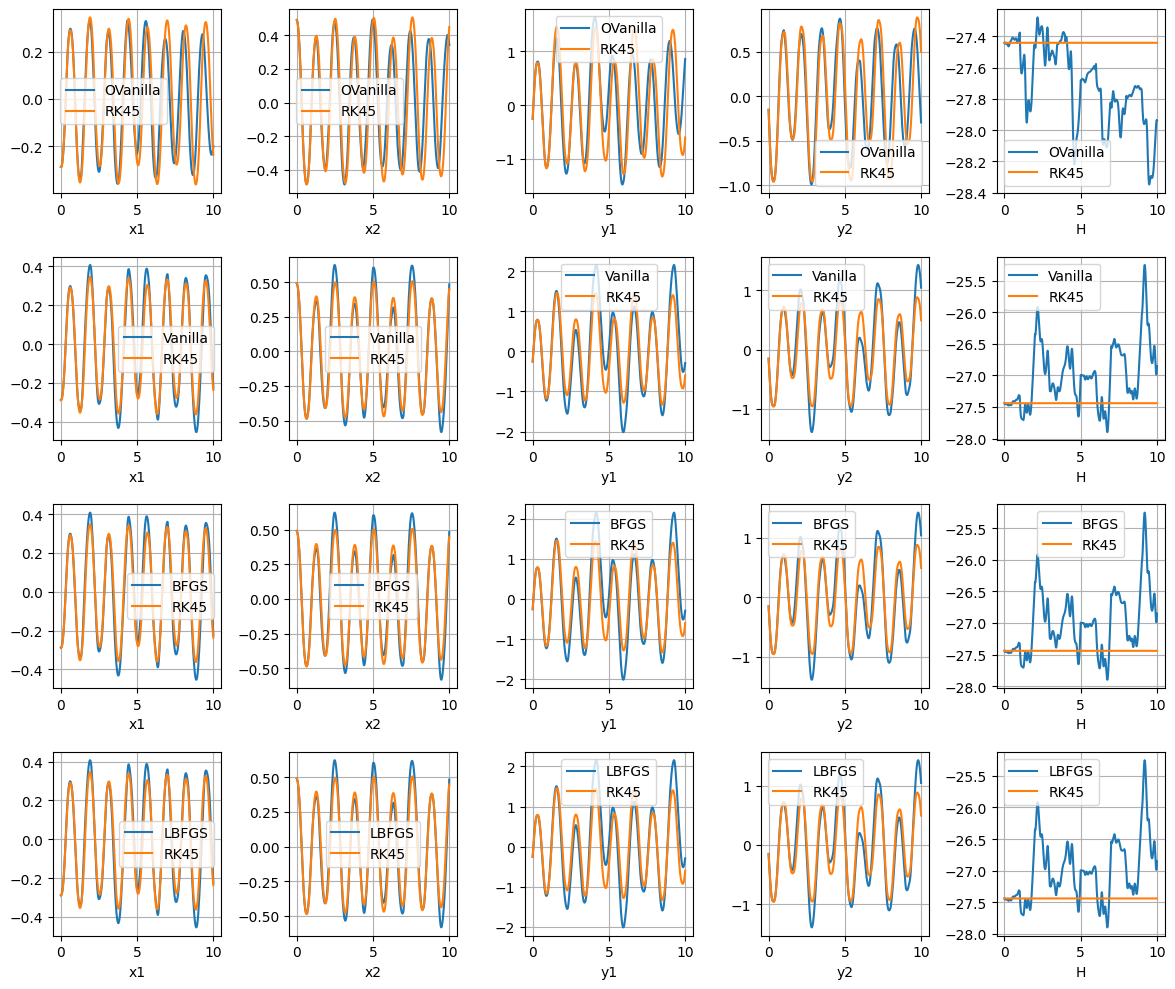

In [86]:
n = 500

t_start = 0.0
t_end = 10.0

n_ts = int(n*(t_end/tfinal))

t_step = t_end/n_ts

num_cycles = math.ceil(n_ts/n)
print(t_step, n_ts, num_cycles)

t_ts = np.linspace(t_start, t_end, n_ts)

x1_init = np.random.uniform(-np.pi/6, np.pi/6, size=(1,))
x2_init = np.random.uniform(-np.pi/6, np.pi/6, size=(1,))
y1_init = np.random.uniform(-np.pi/6, np.pi/6, size=(1,))
y2_init = np.random.uniform(-np.pi/6, np.pi/6, size=(1,))
H_init = (m2*l2**2*y1_init**2 + (m1+m2)*l1**2*y2_init**2 - 2*m2*l1*l2*y1_init*y2_init*jnp.cos(x1_init-x2_init))/(2*m2*l1**2*l2**2*(m1+m2*jnp.sin(x1_init-x2_init)**2))-(m1+m2)*grav*l1*jnp.cos(x1_init)-m2*grav*l2*jnp.cos(x2_init)


# x1_init, x2_init, y1_init, y2_init, H_init = set_vals([[-0.40824746], [-0.21609818], [-0.72853105], [-0.72853105]])

data_rk = np.column_stack([x1_init, x2_init, y1_init, y2_init])
data_rk = np.reshape(data_rk, (-1,))
t_rk = t_ts

sol_rk = odeint(doublePendulum, data_rk, t_rk, rtol = 1e-13, atol = 1e-13)
x1_rk, x2_rk, y1_rk, y2_rk = sol_rk[:, 0], sol_rk[:, 1], sol_rk[:, 2], sol_rk[:, 3]
H_rk = (m2*l2**2*y1_rk**2 + (m1+m2)*l1**2*y2_rk**2 - 2*m2*l1*l2*y1_rk*y2_rk*np.cos(x1_rk-x2_rk))/(2*m2*l1**2*l2**2*(m1+m2*np.sin(x1_rk-x2_rk)**2))-(m1+m2)*grav*l1*np.cos(x1_rk)-m2*grav*l2*np.cos(x2_rk)

x1_pred_ovan, x2_pred_ovan, y1_pred_ovan, y2_pred_ovan, H_pred_ovan = init_preds(n_ts)

x1_pred_van, x2_pred_van, y1_pred_van, y2_pred_van, H_pred_van = init_preds(n_ts)

x1_pred_bfgs, x2_pred_bfgs, y1_pred_bfgs, y2_pred_bfgs, H_pred_bfgs = init_preds(n_ts)

x1_pred_lbfgs, x2_pred_lbfgs, y1_pred_lbfgs, y2_pred_lbfgs, H_pred_lbfgs = init_preds(n_ts)

x1_data_ovan, x1_data_van, x1_data_bfgs, x1_data_lbfgs = x1_init, x1_init, x1_init, x1_init
x2_data_ovan, x2_data_van, x2_data_bfgs, x2_data_lbfgs = x2_init, x2_init, x2_init, x2_init
y1_data_ovan, y1_data_van, y1_data_bfgs, y1_data_lbfgs = y1_init, y1_init, y1_init, y1_init
y2_data_ovan, y2_data_van, y2_data_bfgs, y2_data_lbfgs = y2_init, y2_init, y2_init, y2_init
H_data_ovan, H_data_van, H_data_bfgs, H_data_lbfgs = H_init, H_init, H_init, H_init


t_data = np.linspace(t0, tfinal, n)
t_data_sub = np.linspace(t0 + t_step, tfinal, n)

for i in range(num_cycles) :

    if i != 0 :
        t_data = t_data_sub

    x1_ovan, x2_ovan, y1_ovan, y2_ovan, H_ovan, _, _ = prep_train(t_data, 
                                                   x1_data_ovan, x2_data_ovan, y1_data_ovan, y2_data_ovan, H_data_ovan, 
                                                   Vvar_model, Vparams, n)    

    x1_van, x2_van, y1_van, y2_van, H_van, _, _ = prep_train(t_data, 
                                                   x1_data_van, x2_data_van, y1_data_van, y2_data_van, H_data_van, 
                                                   var_model, params, n)

    x1_bfgs, x2_bfgs, y1_bfgs, y2_bfgs, H_bfgs, _, _ = prep_train(t_data, 
                                                   x1_data_bfgs, x2_data_bfgs, y1_data_bfgs, y2_data_bfgs, H_data_bfgs, 
                                                   Cvar_model, params, n)  
    
    x1_lbfgs, x2_lbfgs, y1_lbfgs, y2_lbfgs, H_lbfgs, _, _ = prep_train(t_data, 
                                                   x1_data_lbfgs, x2_data_lbfgs, y1_data_lbfgs, y2_data_lbfgs, H_data_lbfgs, 
                                                   Cvar_model, Cparams, n)    

    x1_pred_ovan[i*n:(i+1)*n] = x1_ovan
    x2_pred_ovan[i*n:(i+1)*n] = x2_ovan
    y1_pred_ovan[i*n:(i+1)*n] = y1_ovan
    y2_pred_ovan[i*n:(i+1)*n] = y2_ovan
    H_pred_ovan[i*n:(i+1)*n] = H_ovan

    x1_pred_van[i*n:(i+1)*n] = x1_van
    x2_pred_van[i*n:(i+1)*n] = x2_van
    y1_pred_van[i*n:(i+1)*n] = y1_van
    y2_pred_van[i*n:(i+1)*n] = y2_van
    H_pred_van[i*n:(i+1)*n] = H_van
    
    x1_pred_bfgs[i*n:(i+1)*n] = x1_bfgs
    x2_pred_bfgs[i*n:(i+1)*n] = x2_bfgs
    y1_pred_bfgs[i*n:(i+1)*n] = y1_bfgs
    y2_pred_bfgs[i*n:(i+1)*n] = y2_bfgs
    H_pred_bfgs[i*n:(i+1)*n] = H_bfgs
    
    x1_pred_lbfgs[i*n:(i+1)*n] = x1_lbfgs
    x2_pred_lbfgs[i*n:(i+1)*n] = x2_lbfgs
    y1_pred_lbfgs[i*n:(i+1)*n] = y1_lbfgs
    y2_pred_lbfgs[i*n:(i+1)*n] = y2_lbfgs
    H_pred_lbfgs[i*n:(i+1)*n] = H_lbfgs

    x1_data_ovan = x1_pred_ovan[(i+1)*n - 1]
    x2_data_ovan = x2_pred_ovan[(i+1)*n - 1]
    y1_data_ovan = y1_pred_ovan[(i+1)*n - 1]
    y2_data_ovan = y2_pred_ovan[(i+1)*n - 1]
    H_data_ovan = H_pred_ovan[(i+1)*n - 1]
 
    x1_data_van = x1_pred_van[(i+1)*n - 1]
    x2_data_van = x2_pred_van[(i+1)*n - 1]
    y1_data_van = y1_pred_van[(i+1)*n - 1]
    y2_data_van = y2_pred_van[(i+1)*n - 1]
    H_data_van = H_pred_van[(i+1)*n - 1]

    x1_data_bfgs = x1_pred_bfgs[(i+1)*n - 1]
    x2_data_bfgs = x2_pred_bfgs[(i+1)*n - 1]
    y1_data_bfgs = y1_pred_bfgs[(i+1)*n - 1]
    y2_data_bfgs = y2_pred_bfgs[(i+1)*n - 1]
    H_data_bfgs = H_pred_bfgs[(i+1)*n - 1]
    
    x1_data_lbfgs = x1_pred_lbfgs[(i+1)*n - 1]
    x2_data_lbfgs = x2_pred_lbfgs[(i+1)*n - 1]
    y1_data_lbfgs = y1_pred_lbfgs[(i+1)*n - 1]
    y2_data_lbfgs = y2_pred_lbfgs[(i+1)*n - 1]
    H_data_lbfgs = H_pred_lbfgs[(i+1)*n - 1]


fig = plt.figure(figsize=(12, 10))

plt.subplot(4, 5, 1)
plt.tight_layout()
plt.plot(t_ts, x1_pred_ovan)
plt.plot(t_ts, x1_rk)
plt.xlabel("x1")
plt.grid()
plt.legend(['OVanilla','RK45'])

plt.subplot(4, 5, 2)
plt.tight_layout()
plt.plot(t_ts, x2_pred_ovan)
plt.plot(t_ts, x2_rk)
plt.xlabel("x2")
plt.grid()
plt.legend(['OVanilla','RK45'])

plt.subplot(4, 5, 3)
plt.tight_layout()
plt.plot(t_ts, y1_pred_ovan)
plt.plot(t_ts, y1_rk)
plt.xlabel("y1")
plt.grid()
plt.legend(['OVanilla','RK45'])

plt.subplot(4, 5, 4)
plt.tight_layout()
plt.plot(t_ts, y2_pred_ovan)
plt.plot(t_ts, y2_rk)
plt.xlabel("y2")
plt.grid()
plt.legend(['OVanilla','RK45'])

plt.subplot(4, 5, 5)
plt.tight_layout()
plt.plot(t_ts, H_pred_ovan)
plt.plot(t_ts, H_rk)
plt.xlabel("H")
plt.grid()
plt.legend(['OVanilla','RK45'])

plt.subplot(4, 5, 6)
plt.tight_layout()
plt.plot(t_ts, x1_pred_van)
plt.plot(t_ts, x1_rk)
plt.xlabel("x1")
plt.grid()
plt.legend(['Vanilla','RK45'])

plt.subplot(4, 5, 7)
plt.tight_layout()
plt.plot(t_ts, x2_pred_van)
plt.plot(t_ts, x2_rk)
plt.xlabel("x2")
plt.grid()
plt.legend(['Vanilla','RK45'])

plt.subplot(4, 5, 8)
plt.tight_layout()
plt.plot(t_ts, y1_pred_van)
plt.plot(t_ts, y1_rk)
plt.xlabel("y1")
plt.grid()
plt.legend(['Vanilla','RK45'])

plt.subplot(4, 5, 9)
plt.tight_layout()
plt.plot(t_ts, y2_pred_van)
plt.plot(t_ts, y2_rk)
plt.xlabel("y2")
plt.grid()
plt.legend(['Vanilla','RK45'])

plt.subplot(4, 5, 10)
plt.tight_layout()
plt.plot(t_ts, H_pred_van)
plt.plot(t_ts, H_rk)
plt.xlabel("H")
plt.grid()
plt.legend(['Vanilla','RK45'])

plt.subplot(4, 5, 11)
plt.tight_layout()
plt.plot(t_ts, x1_pred_bfgs)
plt.plot(t_ts, x1_rk)
plt.xlabel("x1")
plt.grid()
plt.legend(['BFGS','RK45'])

plt.subplot(4, 5, 12)
plt.tight_layout()
plt.plot(t_ts, x2_pred_bfgs)
plt.plot(t_ts, x2_rk)
plt.xlabel("x2")
plt.grid()
plt.legend(['BFGS','RK45'])

plt.subplot(4, 5, 13)
plt.tight_layout()
plt.plot(t_ts, y1_pred_bfgs)
plt.plot(t_ts, y1_rk)
plt.xlabel("y1")
plt.grid()
plt.legend(['BFGS','RK45'])

plt.subplot(4, 5, 14)
plt.tight_layout()
plt.plot(t_ts, y2_pred_bfgs)
plt.plot(t_ts, y2_rk)
plt.xlabel("y2")
plt.grid()
plt.legend(['BFGS','RK45'])


plt.subplot(4, 5, 15)
plt.tight_layout()
plt.plot(t_ts, H_pred_bfgs)
plt.plot(t_ts, H_rk)
plt.xlabel("H")
plt.grid()
plt.legend(['BFGS','RK45'])

plt.subplot(4, 5, 16)
plt.tight_layout()
plt.plot(t_ts, x1_pred_lbfgs)
plt.plot(t_ts, x1_rk)
plt.xlabel("x1")
plt.grid()
plt.legend(['LBFGS','RK45'])

plt.subplot(4, 5, 17)
plt.tight_layout()
plt.plot(t_ts, x2_pred_lbfgs)
plt.plot(t_ts, x2_rk)
plt.xlabel("x2")
plt.grid()
plt.legend(['LBFGS','RK45'])

plt.subplot(4, 5, 18)
plt.tight_layout()
plt.plot(t_ts, y1_pred_lbfgs)
plt.plot(t_ts, y1_rk)
plt.xlabel("y1")
plt.grid()
plt.legend(['LBFGS','RK45'])

plt.subplot(4, 5, 19)
plt.tight_layout()
plt.plot(t_ts, y2_pred_lbfgs)
plt.plot(t_ts, y2_rk)
plt.xlabel("y2")
plt.grid()
plt.legend(['LBFGS','RK45'])

plt.subplot(4, 5, 20)
plt.tight_layout()
plt.plot(t_ts, H_pred_lbfgs)
plt.plot(t_ts, H_rk)
plt.xlabel("H")
plt.grid()
plt.legend(['LBFGS','RK45'])

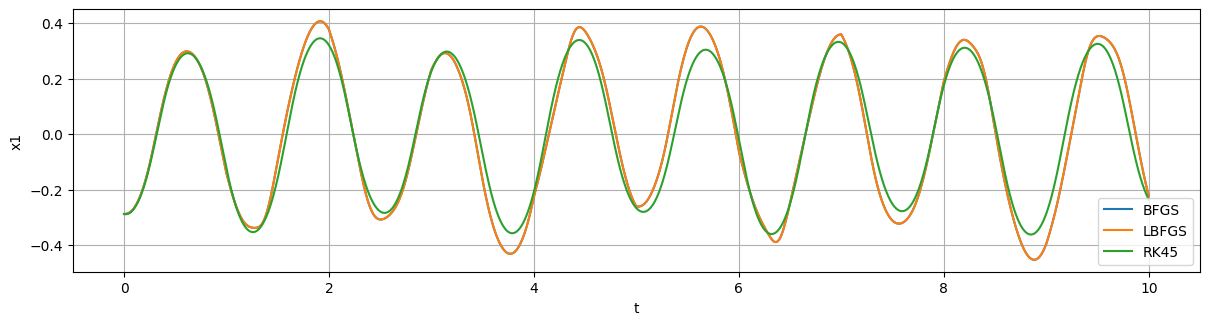

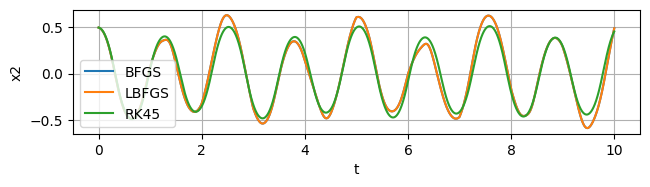

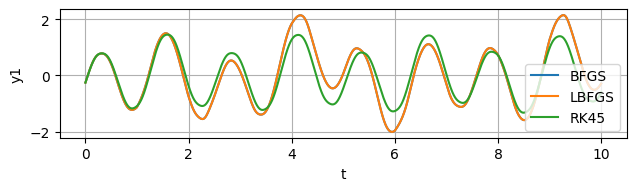

In [87]:
fig = plt.figure(figsize=(12, 9))

plt.subplot(3, 1, 1)
plt.tight_layout()
#plt.plot(t_ts, x1_pred_ovan, label = 'OVanilla')
#plt.plot(t_ts, x1_pred_van, label = 'Vanilla')
plt.plot(t_ts, x1_pred_bfgs, label = 'BFGS')
plt.plot(t_ts, x1_pred_lbfgs, label = 'LBFGS')
plt.plot(t_ts, x1_rk, label = 'RK45')
plt.xlabel("t")
plt.ylabel("x1")
plt.grid()
plt.legend()
plt.show()

plt.subplot(3, 1, 2)
plt.tight_layout()
#plt.plot(t_ts, x2_pred_ovan, label = 'OVanilla')
#plt.plot(t_ts, x2_pred_van, label = 'Vanilla')
plt.plot(t_ts, x2_pred_bfgs, label = 'BFGS')
plt.plot(t_ts, x2_pred_lbfgs, label = 'LBFGS')
plt.plot(t_ts, x2_rk, label = 'RK45')
plt.xlabel("t")
plt.ylabel("x2")
plt.grid()
plt.legend()
plt.show()

plt.subplot(3, 1, 3)
plt.tight_layout()
#plt.plot(t_ts, y1_pred_ovan, label = 'OVanilla')
#plt.plot(t_ts, y1_pred_van, label = 'Vanilla')
plt.plot(t_ts, y1_pred_bfgs, label = 'BFGS')
plt.plot(t_ts, y1_pred_lbfgs, label = 'LBFGS')
plt.plot(t_ts, y1_rk, label = 'RK45')
plt.xlabel("t")
plt.ylabel("y1")
plt.grid()
plt.legend()
plt.show()

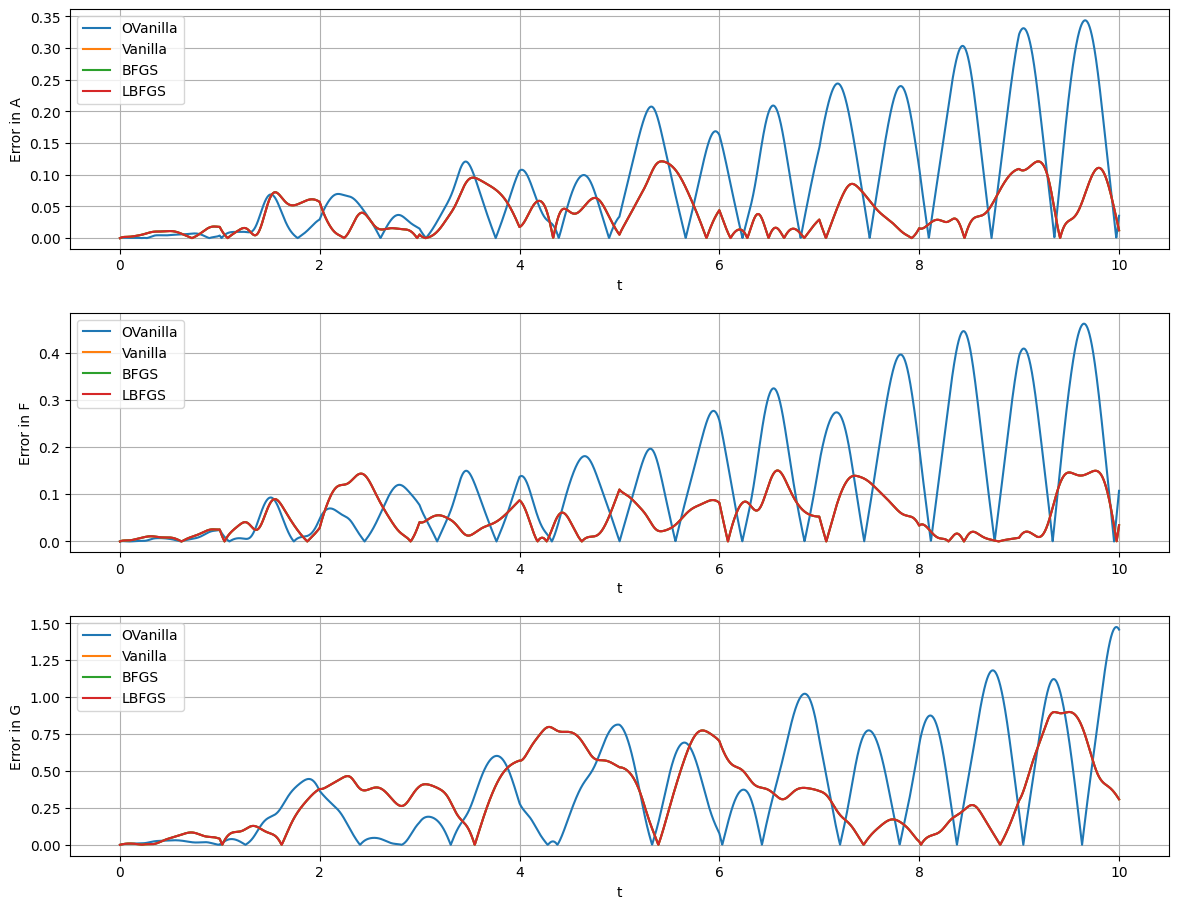

In [88]:
fig = plt.figure(figsize=(12, 9))

plt.subplot(3, 1, 1)
plt.tight_layout()
plt.plot(t_ts, abs(x1_pred_ovan - x1_rk), label = 'OVanilla')
plt.plot(t_ts, abs(x1_pred_van - x1_rk), label = 'Vanilla')
plt.plot(t_ts, abs(x1_pred_bfgs - x1_rk), label = 'BFGS')
plt.plot(t_ts, abs(x1_pred_lbfgs - x1_rk), label = 'LBFGS')
plt.xlabel("t")
plt.ylabel("Error in A")
plt.grid()
plt.legend()

plt.subplot(3, 1, 2)
plt.tight_layout()
plt.plot(t_ts, abs(x2_pred_ovan - x2_rk), label = 'OVanilla')
plt.plot(t_ts, abs(x2_pred_van - x2_rk), label = 'Vanilla')
plt.plot(t_ts, abs(x2_pred_bfgs - x2_rk), label = 'BFGS')
plt.plot(t_ts, abs(x2_pred_lbfgs - x2_rk), label = 'LBFGS')
plt.xlabel("t")
plt.ylabel("Error in F")
plt.grid()
plt.legend()

plt.subplot(3, 1, 3)
plt.tight_layout()
plt.plot(t_ts, abs(y1_pred_ovan - y1_rk), label = 'OVanilla')
plt.plot(t_ts, abs(y1_pred_van - y1_rk), label = 'Vanilla')
plt.plot(t_ts, abs(y1_pred_bfgs - y1_rk), label = 'BFGS')
plt.plot(t_ts, abs(y1_pred_lbfgs - y1_rk), label = 'LBFGS')
plt.xlabel("t")
plt.ylabel("Error in G")
plt.grid()
plt.legend()

Text(0.5, 0, 'G')

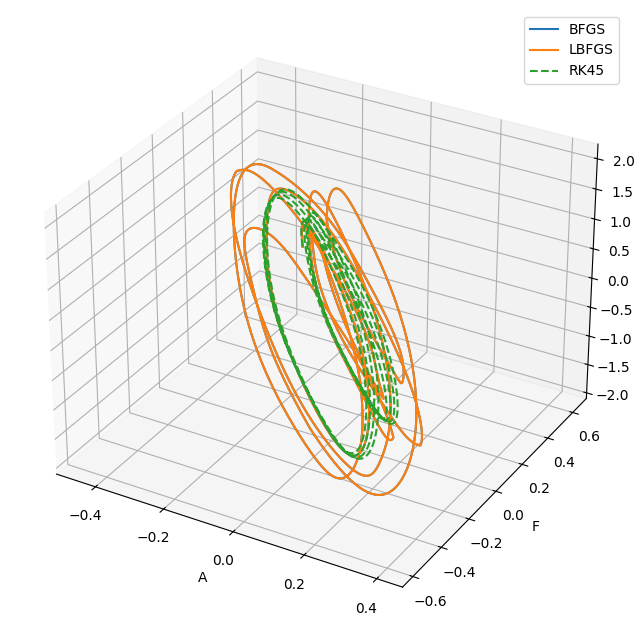

In [89]:
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(projection='3d')
#ax.plot(x1_pred_ovan, x2_pred_ovan, y1_pred_ovan, label='OVanilla')
#ax.plot(x1_pred_van, x2_pred_van, y1_pred_van, label='Vanilla')
ax.plot(x1_pred_bfgs, x2_pred_bfgs, y1_pred_bfgs, label='BFGS')
ax.plot(x1_pred_lbfgs, x2_pred_lbfgs, y1_pred_lbfgs, label='LBFGS')
ax.plot(x1_rk, x2_rk, y1_rk, linestyle='--', label='RK45')
ax.legend()
ax.set_xlabel('A')
ax.set_ylabel('F')
ax.set_zlabel('G')

In [90]:
def compare_methods(num_trials, t_end_val) :

    n = 500
    trials_num = [i+1 for i in range(num_trials)]
    
    t_start = 0.0
    t_end = t_end_val
    
    n_ts = int(n*(t_end/tfinal))
    
    t_step = t_end/n_ts
    
    num_cycles = math.ceil(n_ts/n)
    
    t_ts = np.linspace(t_start, t_end, n_ts)
 
    A_errors_bfgs, F_errors_bfgs, G_errors_bfgs  = [], [], []
    A_errors_lbfgs, F_errors_lbfgs, G_errors_lbfgs = [], [], []
    
    for i in range(num_trials) :

        print("Trial no", i + 1)

        A_init = np.random.uniform(-1.0, 1.0, size=(1,))
        F_init = np.random.uniform(-1.0, 1.0, size=(1,))
        G_init = np.random.uniform(-1.0, 1.0, size=(1,))
        E_init = (1/4)*((A_init**2/l**2) + (F_init**2/k**2) + (2*(G_init**2)/(k**2 + l**2)))
        V_init = (1/2)*(A_init**2 + F_init**2 + 2*(G_init**2))
        
        # A_init, F_init, G_init, E_init, V_init = set_vals([[-0.24342532], [0.31170817], [-0.85430722]])
        
        data_rk = np.column_stack([A_init, F_init, G_init])
        data_rk = np.reshape(data_rk, (-1,))
        t_rk = t_ts
        
        sol_rk = odeint(Lorenz1960, data_rk, t_rk, rtol = 1e-13, atol = 1e-13)
        x1_rk, x2_rk, y1_rk = sol_rk[:,0], sol_rk[:,1], sol_rk[:,2]
        y2_rk = (1/4)*((x1_rk**2/l**2) + (x2_rk**2/k**2) + (2*(y1_rk**2)/(k**2 + l**2)))
        H_rk = (1/2)*(x1_rk**2 + x2_rk**2 + 2*(y1_rk**2))
        
        x1_pred_ovan, x2_pred_ovan, y1_pred_ovan, y2_pred_ovan, H_pred_ovan = init_preds(n_ts)
        
        x1_pred_van, x2_pred_van, y1_pred_van, y2_pred_van, H_pred_van = init_preds(n_ts)
        
        x1_pred_bfgs, x2_pred_bfgs, y1_pred_bfgs, y2_pred_bfgs, H_pred_bfgs = init_preds(n_ts)
        
        x1_pred_lbfgs, x2_pred_lbfgs, y1_pred_lbfgs, y2_pred_lbfgs, H_pred_lbfgs = init_preds(n_ts)
        
        x1_data_ovan, x1_data_van, x1_data_bfgs, x1_data_lbfgs = A_init, A_init, A_init, A_init
        x2_data_ovan, x2_data_van, x2_data_bfgs, x2_data_lbfgs = F_init, F_init, F_init, F_init
        y1_data_ovan, y1_data_van, y1_data_bfgs, y1_data_lbfgs = G_init, G_init, G_init, G_init
        y2_data_ovan, y2_data_van, y2_data_bfgs, y2_data_lbfgs = E_init, E_init, E_init, E_init
        H_data_ovan, H_data_van, H_data_bfgs, H_data_lbfgs = V_init, V_init, V_init, V_init
        
        
        t_data = np.linspace(t0, tfinal, n)
        t_data_sub = np.linspace(t0 + t_step, tfinal, n)
        
        for i in range(num_cycles) :
        
            if i != 0 :
                t_data = t_data_sub
        
            x1_ovan, x2_ovan, y1_ovan, y2_ovan, H_ovan, _, _ = prep_train(t_data, 
                                                           x1_data_ovan, x2_data_ovan, y1_data_ovan, y2_data_ovan, H_data_ovan, 
                                                           Vvar_model, Vparams, n)    
        
            x1_van, x2_van, y1_van, y2_van, H_van, _, _ = prep_train(t_data, 
                                                           x1_data_van, x2_data_van, y1_data_van, y2_data_van, H_data_van, 
                                                           var_model, params, n)
        
            x1_bfgs, x2_bfgs, y1_bfgs, y2_bfgs, H_bfgs, _, _ = prep_train(t_data, 
                                                           x1_data_bfgs, x2_data_bfgs, y1_data_bfgs, y2_data_bfgs, H_data_bfgs, 
                                                           Cvar_model, params, n)  
            
            x1_lbfgs, x2_lbfgs, y1_lbfgs, y2_lbfgs, H_lbfgs, _, _ = prep_train(t_data, 
                                                           x1_data_lbfgs, x2_data_lbfgs, y1_data_lbfgs, y2_data_lbfgs, H_data_lbfgs, 
                                                           Cvar_model, Cparams, n)    
        
            x1_pred_ovan[i*n:(i+1)*n] = x1_ovan
            x2_pred_ovan[i*n:(i+1)*n] = x2_ovan
            y1_pred_ovan[i*n:(i+1)*n] = y1_ovan
            y2_pred_ovan[i*n:(i+1)*n] = y2_ovan
            H_pred_ovan[i*n:(i+1)*n] = H_ovan
        
            x1_pred_van[i*n:(i+1)*n] = x1_van
            x2_pred_van[i*n:(i+1)*n] = x2_van
            y1_pred_van[i*n:(i+1)*n] = y1_van
            y2_pred_van[i*n:(i+1)*n] = y2_van
            H_pred_van[i*n:(i+1)*n] = H_van
            
            x1_pred_bfgs[i*n:(i+1)*n] = x1_bfgs
            x2_pred_bfgs[i*n:(i+1)*n] = x2_bfgs
            y1_pred_bfgs[i*n:(i+1)*n] = y1_bfgs
            y2_pred_bfgs[i*n:(i+1)*n] = y2_bfgs
            H_pred_bfgs[i*n:(i+1)*n] = H_bfgs
            
            x1_pred_lbfgs[i*n:(i+1)*n] = x1_lbfgs
            x2_pred_lbfgs[i*n:(i+1)*n] = x2_lbfgs
            y1_pred_lbfgs[i*n:(i+1)*n] = y1_lbfgs
            y2_pred_lbfgs[i*n:(i+1)*n] = y2_lbfgs
            H_pred_lbfgs[i*n:(i+1)*n] = H_lbfgs
        
            x1_data_ovan = x1_pred_ovan[(i+1)*n - 1]
            x2_data_ovan = x2_pred_ovan[(i+1)*n - 1]
            y1_data_ovan = y1_pred_ovan[(i+1)*n - 1]
            y2_data_ovan = y2_pred_ovan[(i+1)*n - 1]
            H_data_ovan = H_pred_ovan[(i+1)*n - 1]
         
            x1_data_van = x1_pred_van[(i+1)*n - 1]
            x2_data_van = x2_pred_van[(i+1)*n - 1]
            y1_data_van = y1_pred_van[(i+1)*n - 1]
            y2_data_van = y2_pred_van[(i+1)*n - 1]
            H_data_van = H_pred_van[(i+1)*n - 1]
        
            x1_data_bfgs = x1_pred_bfgs[(i+1)*n - 1]
            x2_data_bfgs = x2_pred_bfgs[(i+1)*n - 1]
            y1_data_bfgs = y1_pred_bfgs[(i+1)*n - 1]
            y2_data_bfgs = y2_pred_bfgs[(i+1)*n - 1]
            H_data_bfgs = H_pred_bfgs[(i+1)*n - 1]
            
            x1_data_lbfgs = x1_pred_lbfgs[(i+1)*n - 1]
            x2_data_lbfgs = x2_pred_lbfgs[(i+1)*n - 1]
            y1_data_lbfgs = y1_pred_lbfgs[(i+1)*n - 1]
            y2_data_lbfgs = y2_pred_lbfgs[(i+1)*n - 1]
            H_data_lbfgs = H_pred_lbfgs[(i+1)*n - 1]

        # fig = plt.figure(figsize=(8,8))
        # ax = fig.add_subplot(projection='3d')
        # #ax.plot(x1_pred_ovan, x2_pred_ovan, y1_pred_ovan, label='OVanilla')
        # #ax.plot(x1_pred_van, x2_pred_van, y1_pred_van, label='Vanilla')
        # ax.plot(x1_pred_bfgs, x2_pred_bfgs, y1_pred_bfgs, label='BFGS')
        # ax.plot(x1_pred_lbfgs, x2_pred_lbfgs, y1_pred_lbfgs, label='LBFGS')
        # ax.plot(x1_rk, x2_rk, y1_rk, linestyle='--', label='RK45')
        # ax.legend()
        # ax.set_xlabel('A')
        # ax.set_ylabel('F')
        # ax.set_zlabel('G')
        # plt.show()
        
        A_err_bfgs = np.mean(np.abs(x1_pred_bfgs - x1_rk))
        F_err_bfgs = np.mean(np.abs(x2_pred_bfgs - x2_rk))
        G_err_bfgs = np.mean(np.abs(y1_pred_bfgs - y1_rk))

        A_err_lbfgs = np.mean(np.abs(x1_pred_lbfgs - x1_rk))
        F_err_lbfgs = np.mean(np.abs(x2_pred_lbfgs - x2_rk))
        G_err_lbfgs = np.mean(np.abs(y1_pred_lbfgs - y1_rk))

        A_errors_bfgs.append(A_err_bfgs)
        F_errors_bfgs.append(F_err_bfgs)
        G_errors_bfgs.append(G_err_bfgs)

        A_errors_lbfgs.append(A_err_lbfgs)
        F_errors_lbfgs.append(F_err_lbfgs)
        G_errors_lbfgs.append(G_err_lbfgs)


    fig = plt.figure(figsize=(12, 9))
    
    plt.subplot(3, 1, 1)
    plt.tight_layout()
    plt.plot(trials_num, A_errors_bfgs, label = 'BFGS')
    plt.plot(trials_num, A_errors_lbfgs, label = 'LBFGS')
    plt.xlabel("Trial no")
    plt.ylabel("MAE in A")
    plt.xticks(trials_num)
    plt.grid()
    plt.legend()
    
    plt.subplot(3, 1, 2)
    plt.tight_layout()
    plt.plot(trials_num, F_errors_bfgs, label = 'BFGS')
    plt.plot(trials_num, F_errors_lbfgs, label = 'LBFGS')
    plt.xlabel("Trial no")
    plt.ylabel("MAE in F")
    plt.xticks(trials_num)
    plt.grid()
    plt.legend()
    
    plt.subplot(3, 1, 3)
    plt.tight_layout()
    plt.plot(trials_num, G_errors_bfgs, label = 'BFGS')
    plt.plot(trials_num, G_errors_lbfgs, label = 'LBFGS')
    plt.xlabel("Trial no")
    plt.ylabel("MAE in G")
    plt.xticks(trials_num)
    plt.grid()
    plt.legend()
    
    plt.show()
    
    return 

In [91]:
# compare_methods(100, 50.0)

In [92]:
# _, _, Vparams_flat = flatten_pytree(Vparams)
# jnp.save("V_t1.0_1000_5000_ep_DP", Vparams_flat)

# _, _, params_flat = flatten_pytree(params)
# jnp.save("P_t1.0_1000_5000_ep_DP", params_flat)